<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/10_visualization_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 10 — Visualisation with Seaborn

> **Advanced & Self-Learning Track — Notebook 10 of 15** · **Estimated time:** 50–60 min · **Difficulty:** Beginner / Intermediate
>
> This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

### 🔗 Building on Track 1

The live session's optional bonus notebook, [`../01_introduction/06_seaborn_intro.ipynb`](../01_introduction/06_seaborn_intro.ipynb), drew three seaborn charts on a twelve-row table to make one point: you name columns, seaborn draws. Everything below is new — the data *shape* seaborn insists on, the two families of plotting functions, distributions and categorical comparisons, faceting, colour you can defend, and the point where the library stops helping. Nothing from the live session is assumed, so a cold start here costs you nothing.

[Notebook 9](09_visualization_matplotlib.ipynb) taught the engine: Figure and Axes, one chart type per question, and the labelling discipline that keeps a chart honest. Seaborn is a **layer on top of that engine**, not a replacement for it — every chart in this notebook is a matplotlib chart underneath, which is exactly why you can still reach in and fix it by hand.

**What the layer buys you** is three things you would otherwise write out every single time:

1. **Statistical transformation.** `histplot` bins, `kdeplot` estimates a density, `barplot` aggregates, `ecdfplot` accumulates, `regplot` fits a line *and* bootstraps a confidence band. Each is one function call instead of a block of preparation code.
2. **Mapping columns to visual channels.** `hue=`, `size=`, `style=`, `col=`, `row=` — colour, marker size, marker shape and whole grids of panels, driven straight from column names, legend included.
3. **Defaults with taste.** Coordinated palettes, sane ticks, readable spacing, a legend where one is needed.

The price is a mental model you have to actually learn: **long data, and two families of functions.** Get those two right and the rest of seaborn is a lookup table.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Set a consistent look for a whole notebook with **`sns.set_theme()`**, and know which matplotlib settings it overwrote.
2. Recognise **long ("tidy") data**, reshape wide data into it with `melt`, and name the symptom that tells you seaborn is being handed the wrong shape.
3. Tell **axes-level** functions (`histplot`, `boxplot`, `scatterplot`, …) from **figure-level** ones (`displot`, `catplot`, `relplot`, `lmplot`) — and pick the right one on purpose.
4. Choose within the three families by **the question**: distribution, relationship, or comparison between categories.
5. **Facet** with `col=` / `row=` / `hue=`, and say why shared axes are what make small multiples comparable.
6. Draw **heatmaps** from `pivot_table` output and a **pairplot** as a first look at a table.
7. Pick a **categorical, sequential or diverging palette** deliberately, and check it survives colour blindness.
8. Drop back into **matplotlib** to annotate, add a reference line, fix labels and save — on both an Axes and a `FacetGrid`.
9. Say, for any seaborn chart, **what statistic it computed for you** and what that statistic hides.

## ✅ Prerequisites

Notebooks 1–9 of this track. Three matter most: [`07_pandas_essentials.ipynb`](07_pandas_essentials.ipynb) (`groupby`, `pivot_table` and the DataFrames we plot), [`08_data_cleaning_preprocessing.ipynb`](08_data_cleaning_preprocessing.ipynb) (a beautiful chart of dirty data is a lie told fluently), and [`09_visualization_matplotlib.ipynb`](09_visualization_matplotlib.ipynb) (Figure/Axes, chart choice, and how charts mislead — all of which still applies here).

⬅️ **Previous:** [`09_visualization_matplotlib.ipynb`](09_visualization_matplotlib.ipynb) · ➡️ **Next:** [`11_exploratory_data_analysis.ipynb`](11_exploratory_data_analysis.ipynb)

## 1. Setup — one import, one theme call

Two imports and one line of styling. `sns.set_theme()` is the seaborn habit worth copying: it writes matplotlib's `rcParams` **globally**, so every chart in the notebook — seaborn *and* plain matplotlib — inherits the same look.

Its three arguments are worth knowing by name:

- **`style=`** — the background: `"whitegrid"`, `"darkgrid"`, `"white"`, `"ticks"`.
- **`context=`** — how big everything is drawn: `"paper"` → `"notebook"` → `"talk"` → `"poster"`. Same chart, bigger fonts and lines. Use `"talk"` for slides and stop hand-tuning font sizes.
- **`palette=`** — the default colour cycle for categories.

> 🎨 The palette below is the [Bridging AI & Society](https://bridgingaiandsociety.org) summer-school brand palette, the same one used in Notebook 9.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE   = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK    = "#1c2025"   # brand ink — text, annotations
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / thresholds
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

# One call, and every chart below — seaborn or matplotlib — inherits this look.
sns.set_theme(style="whitegrid", context="notebook", palette=BAS_PALETTE)
plt.rcParams["figure.dpi"] = 100
# ---------------------------------------------------------------------------

print(f"seaborn    : {sns.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"pandas     : {pd.__version__}")

seaborn    : 0.13.2
matplotlib : 3.9.4
pandas     : 2.3.3


## 2. The data: 960 air-quality readings, built here

Seaborn ships a set of example tables — `sns.load_dataset("penguins")`, `"tips"`, `"flights"` — and every seaborn tutorial on the internet uses them. They are genuinely convenient, with one catch: **`load_dataset` downloads from GitHub**, so it fails behind a firewall or on a machine without a network. This course promises every notebook runs anywhere, so we generate our own table instead — and generating it has a side benefit: we know exactly what is in it, so we can check whether the charts tell the truth.

The scenario: **fine-particulate (PM2.5) monitoring** in five European cities, one year, two kinds of district. PM2.5 is the pollutant with the clearest link to mortality, it is measured in µg/m³, and it varies both by *place* and by *season* — which makes it a good workout for every chart type below.

Written into the generator, so we can check for them later: a **city baseline**, a **winter peak** (heating and cold-air inversions), a **traffic effect**, a small **rain washout effect**, and an **inner-city penalty** — the same city is dirtier where people live densest.

In [2]:
rng = np.random.default_rng(42)

CITIES = {                 # city   : (baseline PM2.5, seasonal swing, mean temperature)
    "Bergen": ( 8,  2,  8),
    "Berlin": (14,  5, 10),
    "Madrid": (16,  4, 15),
    "Warsaw": (22, 11,  9),
    "Milan" : (26, 12, 13),
}
MONTHS, DISTRICTS, PER_GROUP = range(1, 13), ("inner", "outer"), 8

records = []
for city, (base, swing, t_mean) in CITIES.items():
    for month in MONTHS:
        winter = np.cos((month - 1) / 12 * 2 * np.pi)      # +1 in January, −1 in July
        for district in DISTRICTS:
            traffic = rng.normal(72 if district == "inner" else 44, 9, PER_GROUP).clip(5, 100)
            rain    = rng.gamma(2.0, 18 + 6 * winter, PER_GROUP)
            temp    = t_mean - 9 * winter + rng.normal(0, 1.5, PER_GROUP)
            pm25    = (base + swing * winter          # place and season
                       + 0.18 * (traffic - 55)        # traffic
                       - 0.04 * rain                  # rain washes particles out
                       + rng.normal(0, 2.5, PER_GROUP)).clip(1, None)
            records.append(pd.DataFrame({
                "city": city, "month": month, "district": district,
                "pm25": pm25.round(1), "temperature_c": temp.round(1),
                "traffic_index": traffic.round(0), "rainfall_mm": rain.round(1),
            }))

air = pd.concat(records, ignore_index=True)

print("shape:", air.shape)
air.head()

shape: (960, 7)


,city,month,district,pm25,temperature_c,traffic_index,rainfall_mm
0,Bergen,1,inner,10.7,-1.6,75.0,39.5
1,Bergen,1,inner,6.4,-1.5,63.0,73.9
2,Bergen,1,inner,14.1,-0.2,79.0,42.1
3,Bergen,1,inner,15.2,-0.5,80.0,56.3
4,Bergen,1,inner,7.5,-0.4,54.0,52.5


**One row is one reading**: a city, a month, a district type, and four measurements. 5 cities × 12 months × 2 districts × 8 readings = **960 rows**, 7 columns.

> ⚠️ **The data is synthetic.** The mechanisms are real (winter inversions, traffic, rain washout, inner-city exposure); these particular numbers are invented, so no figure below is a fact about Milan or Bergen. What *is* real is the reasoning: every claim we make from a chart, we can check against the generator above — a luxury you will never have again, and a good way to learn what charts can and cannot support.

## 3. Long data — the one thing to get right

Almost every seaborn question on the internet is really this question. Seaborn wants **long** (also called *tidy*) data:

> **one row per observation, one column per variable.**

`air` is already long: each row is one reading, and `city`, `month`, `district` and `pm25` are each a single column. That is what makes `x="month", y="pm25", hue="district"` possible — every visual channel is *a column name*.

The alternative shape is **wide**, which is how humans like to read tables and how spreadsheets export them: one row per month, one column per city, the measurement spread across the columns. Wide data has no column called "city" — the cities *are* the columns — so there is nothing to hand to `hue=`.

In [3]:
# Wide: the shape a spreadsheet gives you. Cities are COLUMNS.
wide = air.pivot_table(index="month", columns="city", values="pm25", aggfunc="mean").round(1)
wide.head(3)

city,Bergen,Berlin,Madrid,Milan,Warsaw
month,,,,,
1,8.7,18.5,17.6,34.0,31.5
2,8.4,17.8,17.6,35.3,30.8
3,7.2,16.3,16.9,31.4,27.1


In [4]:
# Long: one row per (month, city) pair. "city" is a COLUMN again, so hue= can use it.
long = wide.reset_index().melt(id_vars="month", var_name="city", value_name="pm25")

print(long.shape)
long.head(3)

(60, 3)


,month,city,pm25
0,1,Bergen,8.7
1,2,Bergen,8.4
2,3,Bergen,7.2


`melt` is the wide→long converter, and its three arguments are the whole story: `id_vars` are the columns to keep as they are, `var_name` names the new column made out of the old *column headers*, and `value_name` names the new column made out of the *cells*. (Its inverse is `pivot`/`pivot_table`, from Notebook 7 — you will go back and forth constantly.)

Seaborn does have partial **wide-form support**: hand a whole DataFrame to `sns.lineplot(data=wide)` and it will plot every column as a series. It is a genuine convenience for a quick look, and it is a dead end — `hue`, `col`, `style` and `size` all need a column to point at. Both calls below draw the same five lines; only the second one can be extended.

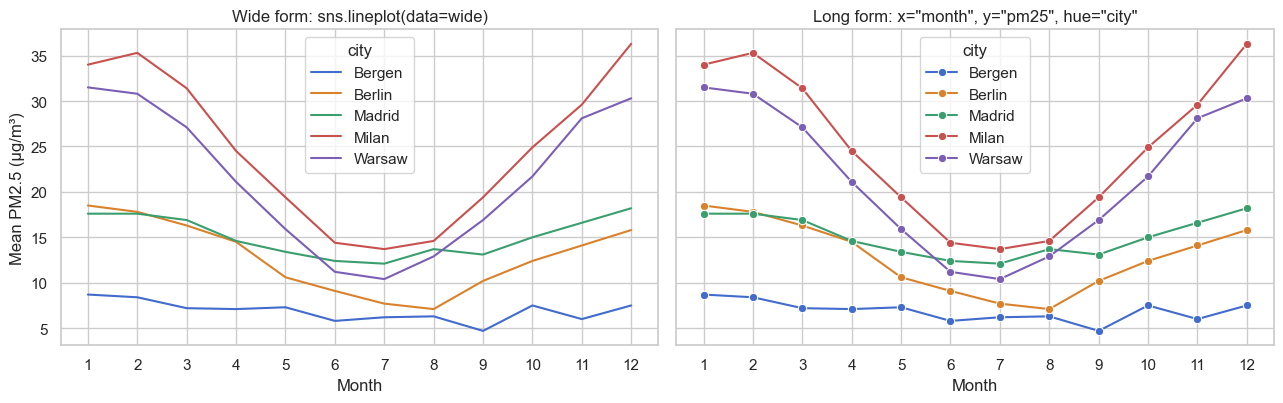

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

# Wide form: no x=, no y=, no hue= — seaborn plots every column as a series.
sns.lineplot(data=wide, ax=axes[0], dashes=False)
axes[0].set_title("Wide form: sns.lineplot(data=wide)")
axes[0].set_ylabel("Mean PM2.5 (µg/m³)")

# Long form: every channel is a column name.
sns.lineplot(data=long, x="month", y="pm25", hue="city", marker="o", ax=axes[1])
axes[1].set_title('Long form: x="month", y="pm25", hue="city"')

for ax in axes:
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

**The symptoms of wide data handed to a long-data function** are worth memorising, because the error messages are not obvious:

| Symptom | What happened |
|---|---|
| `ValueError: Could not interpret value 'city' for 'hue'` | there is no `city` column — the cities are column headers |
| every series drawn in the same colour, no legend | you passed the frame but no `hue=` |
| one enormous bar or a single flat line | seaborn aggregated across columns you meant to keep separate |
| `KeyError: 'pm25'` after a `pivot_table` | the values column became the *cells*; it no longer has a name of its own |

Reflex: **`.melt()` first, plot second.** And keep the long frame around — every chart in the rest of this notebook is drawn straight off `air`.

## 4. Two families: axes-level and figure-level

The other thing that confuses everyone. Seaborn has two kinds of plotting function, and they behave differently in ways that matter the moment you want more than one panel.

**Axes-level** functions — `histplot`, `kdeplot`, `ecdfplot`, `scatterplot`, `lineplot`, `boxplot`, `violinplot`, `stripplot`, `barplot`, `countplot`, `pointplot`, `regplot`, `heatmap` — draw onto **one Axes**. They accept `ax=`, they return that Axes, and they fit inside a matplotlib layout you built yourself. They are the ones to use when *you* are in charge of the figure.

**Figure-level** functions — `displot`, `relplot`, `catplot`, `lmplot`, `pairplot`, `jointplot` — own their **whole figure**. They create it, they size it with `height=` and `aspect=` (not `figsize=`), they ignore any figure you made before calling them, and they return a **grid object** (`FacetGrid`, `PairGrid`, `JointGrid`) instead of an Axes. In exchange they can split your data into a grid of panels with `col=` and `row=`, which axes-level functions cannot do.

Each figure-level function is a doorway onto a family of axes-level ones, selected with `kind=`:

| Figure-level | `kind=` options | Axes-level equivalent | The question |
|---|---|---|---|
| **`displot`** | `hist`, `kde`, `ecdf` | `histplot`, `kdeplot`, `ecdfplot` | how is one variable distributed? |
| **`relplot`** | `scatter`, `line` | `scatterplot`, `lineplot` | how do two variables relate? |
| **`catplot`** | `strip`, `swarm`, `box`, `violin`, `boxen`, `bar`, `count`, `point` | `stripplot`, `boxplot`, … | how do categories compare? |
| **`lmplot`** | *(none — always a regression)* | `regplot` | what does a fitted line look like? |

**How to choose:** need `col=`/`row=` faceting → figure-level. Need this chart to be one panel of a dashboard you are assembling → axes-level with `ax=`. That is the entire decision.

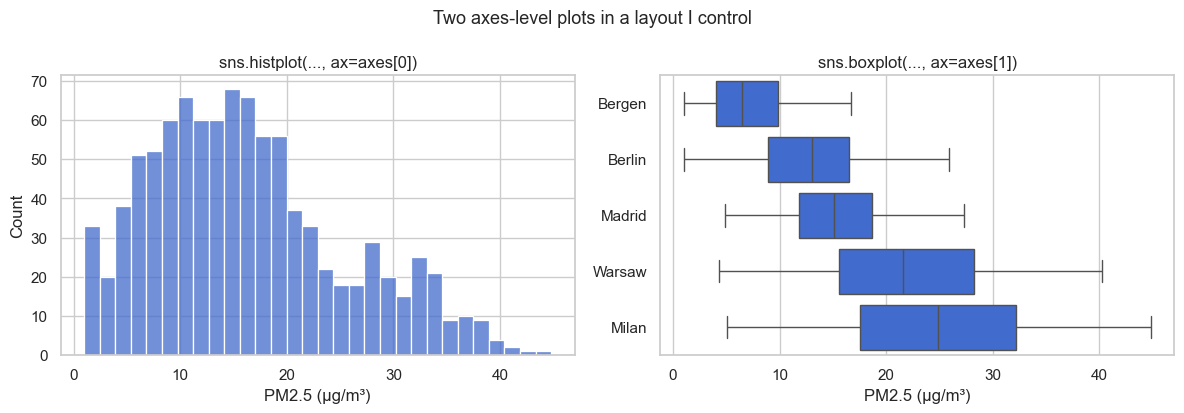

In [6]:
# Axes-level: I build the figure, seaborn fills the panels I hand it.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(data=air, x="pm25", bins=30, color=BAS_BLUE, ax=axes[0])
axes[0].set_title("sns.histplot(..., ax=axes[0])")
axes[0].set_xlabel("PM2.5 (µg/m³)")

sns.boxplot(data=air, x="pm25", y="city", color=BAS_BLUE, saturation=1, ax=axes[1])
axes[1].set_title("sns.boxplot(..., ax=axes[1])")
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].set_ylabel("")

fig.suptitle("Two axes-level plots in a layout I control", fontsize=13)
plt.tight_layout()
plt.show()

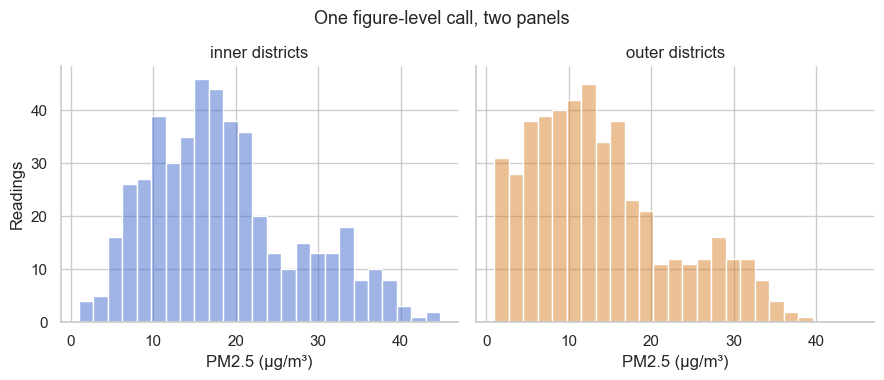

<class 'seaborn.axisgrid.FacetGrid'>
(1, 2) panels


In [7]:
# Figure-level: seaborn builds the figure. Note height/aspect instead of figsize,
# and that the return value is a grid object, not an Axes.
g = sns.displot(data=air, x="pm25", col="district", hue="district",
                bins=25, height=3.6, aspect=1.25, legend=False)
g.set_axis_labels("PM2.5 (µg/m³)", "Readings")
g.set_titles("{col_name} districts")
g.figure.suptitle("One figure-level call, two panels", y=1.05, fontsize=13)
plt.show()

print(type(g))                     # FacetGrid — not an Axes
print(g.axes.shape, "panels")      # the Axes it created, if you need them

Same library, two contracts. The figure-level call produced **two panels from one line** — that is `col=`, and it is the reason the family exists. It also silently ignored anything you might have done with `plt.figure(figsize=...)` first, which is pitfall number one in section 12.

Note what came back: a `FacetGrid`, whose useful methods are `set_axis_labels`, `set_titles` (with `{col_name}` / `{row_name}` placeholders), `refline`, `add_legend`, `tight_layout` and `savefig` — plus `g.figure` and `g.axes` when you need the matplotlib objects underneath. There is no `g.set_title`; a figure-level chart's overall title goes on `g.figure.suptitle`.

## 5. Distributions — three views of one column

"How is this variable distributed?" is the first question to ask about any numeric column, and seaborn gives you three answers with different trade-offs. Drawn side by side, with `hue="district"` splitting each one, they are easy to compare.

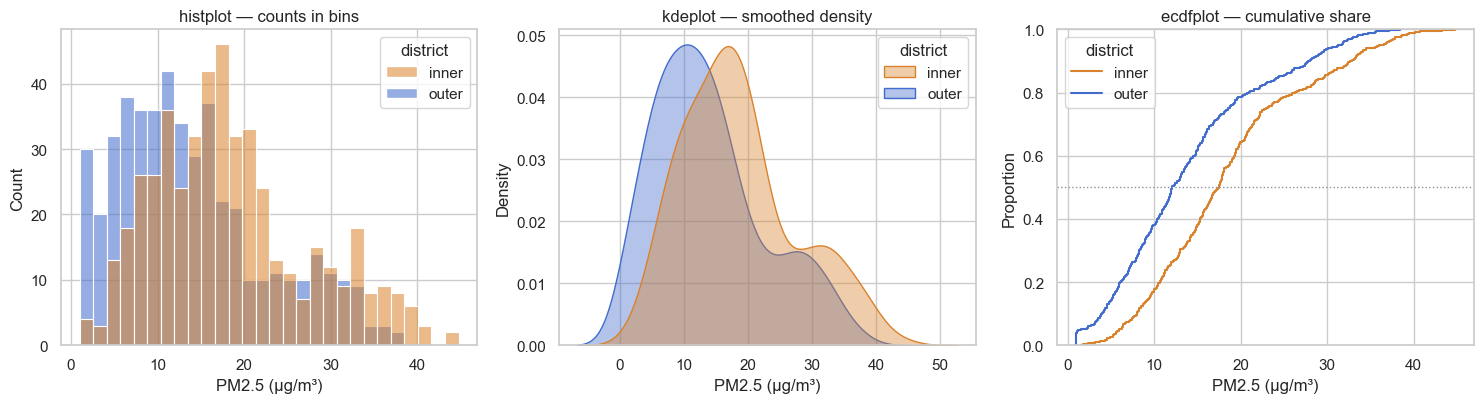

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
pal = {"inner": BAS_AMBER, "outer": BAS_BLUE}

sns.histplot(data=air, x="pm25", hue="district", palette=pal,
             bins=28, multiple="layer", alpha=.55, ax=axes[0])
axes[0].set_title("histplot — counts in bins")

sns.kdeplot(data=air, x="pm25", hue="district", palette=pal,
            fill=True, common_norm=False, alpha=.4, ax=axes[1])
axes[1].set_title("kdeplot — smoothed density")

sns.ecdfplot(data=air, x="pm25", hue="district", palette=pal, ax=axes[2])
axes[2].axhline(0.5, color=BAS_GREY, lw=1, ls=":")
axes[2].set_title("ecdfplot — cumulative share")

for ax in axes:
    ax.set_xlabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

**All three say the same thing about our data** — inner-city readings sit to the right of outer-district ones (means 18.6 vs 13.9 µg/m³) — and each says it differently:

- **`histplot`** counts readings into bins. Honest and literal, but the picture depends on `bins=`: too few hides structure, too many turns the distribution into noise. Always try a second value before believing a shape. `multiple=` decides how the groups share the space — `"layer"` (overlaid, as here), `"stack"`, `"dodge"` or `"fill"` (proportions).
- **`kdeplot`** smooths the histogram into a density. Easier to compare across groups, at the price of *inventing* smoothness the data never had, and of spilling probability past the ends of the real range — you can see the curves reaching left of the physical minimum. `common_norm=False` is almost always what you want with `hue`: it normalises each group separately, so two groups of unequal size are still comparable in shape.
- **`ecdfplot`** plots, for each value on the x-axis, the share of readings at or below it. Nothing is binned, nothing is smoothed, nothing is invented, and it answers threshold questions directly: read up from 15 µg/m³ and you get **62% of outer readings** below it against **37% of inner ones**. Its cost is that it is less intuitive — a hump is easier to see than a slope.

**Rule of thumb:** histogram to *look*, ECDF to *argue* (especially about thresholds), KDE only when a smooth comparison of shapes is the actual point.

## 6. Relationships — scatter, and the line through it

Two numeric columns, one question: do they move together? `scatterplot` shows the raw pairs; `regplot` adds a fitted line and a bootstrapped 95% confidence band around it.

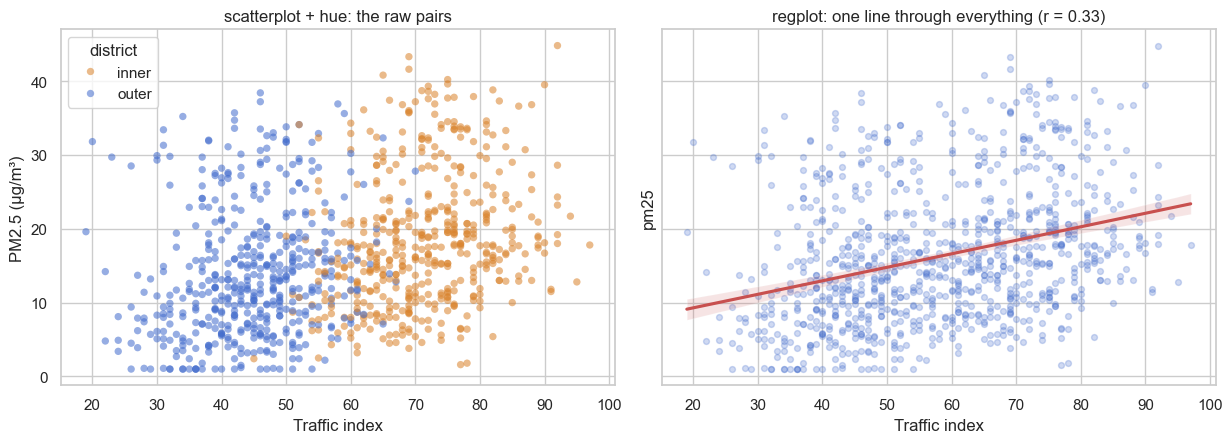

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

sns.scatterplot(data=air, x="traffic_index", y="pm25", hue="district",
                palette=pal, alpha=.55, s=28, edgecolor="none", ax=axes[0])
axes[0].set_title("scatterplot + hue: the raw pairs")

sns.regplot(data=air, x="traffic_index", y="pm25", scatter_kws=dict(alpha=.25, s=18),
            line_kws=dict(color=BAS_RED), color=BAS_BLUE, ax=axes[1])
axes[1].set_title("regplot: one line through everything (r = 0.33)")

for ax in axes:
    ax.set_xlabel("Traffic index")
axes[0].set_ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

**Reading the left panel.** Two clouds, not one: outer districts cluster around a traffic index of 44, inner districts around 71 — because that is how the generator built them. `hue=` did the work of making that visible; without it you would see a single smear and read a stronger traffic effect than exists.

**Reading the right panel.** `regplot` fitted one line to all 960 points and reports the pooled relationship, r = **0.33**. The shaded band is a confidence interval on the *line*, not a prediction interval for points — with 960 rows it is so narrow it nearly disappears, which is a good reminder that "statistically clear" and "practically large" are different claims.

And that pooled 0.33 is partly an illusion, which is what the next cell is for. `lmplot` is `regplot`'s figure-level sibling: same fit, but it can facet.

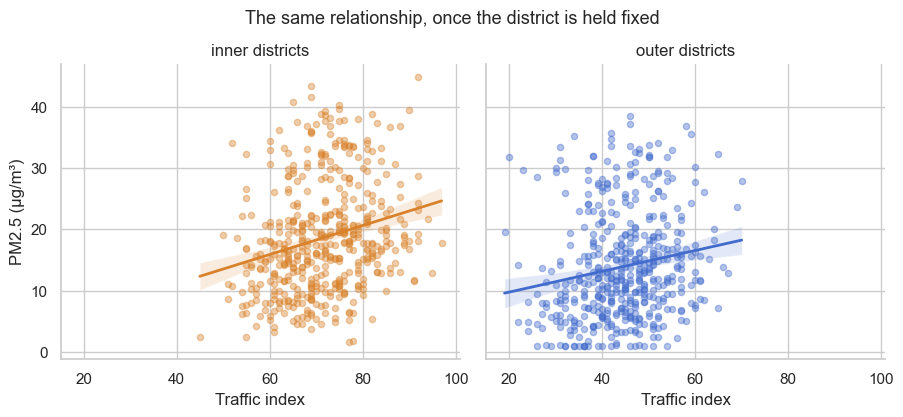

inner: r = 0.24
outer: r = 0.17


In [10]:
g = sns.lmplot(data=air, x="traffic_index", y="pm25", col="district", hue="district",
               palette=pal, height=4, aspect=1.15,
               scatter_kws=dict(alpha=.4, s=20), line_kws=dict(lw=2))
g.set_axis_labels("Traffic index", "PM2.5 (µg/m³)")
g.set_titles("{col_name} districts")
g.figure.suptitle("The same relationship, once the district is held fixed", y=1.04, fontsize=13)
plt.show()

for name, part in air.groupby("district"):
    print(f"{name}: r = {part['pm25'].corr(part['traffic_index']):.2f}")

**The pooled slope was flattered by the grouping.** Within a district type the correlation drops to **0.24** (inner) and **0.17** (outer): a good part of that pooled 0.33 was not traffic at all, but the fact that inner districts have *both* more traffic *and* — for other reasons entirely — more particulate matter. Splitting the panels separated the two stories.

This is the same family of trap as the confounded aggregates in [Notebook 11](11_exploratory_data_analysis.ipynb), and `col=` is the cheapest instrument for finding it: **facet by anything that might be driving both axes, and see whether your relationship survives.** Here it survives, smaller. Sometimes it vanishes; occasionally it changes sign.

## 7. The categorical family — comparing groups

Category on one axis, numbers on the other. Seaborn offers half a dozen ways to draw that, they are *not* interchangeable, and the choice is about how much of the distribution you are willing to hide. Same data in all four panels below.

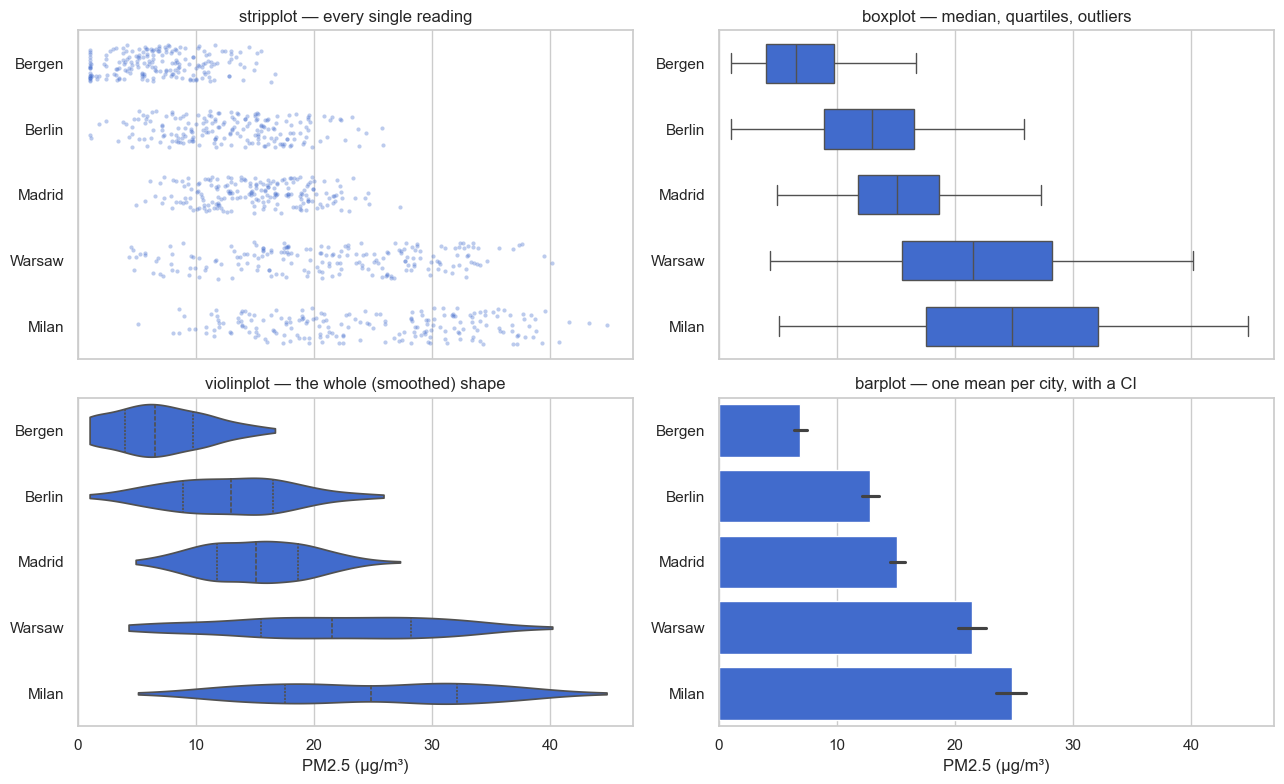

In [11]:
order = air.groupby("city")["pm25"].median().sort_values().index   # weakest → dirtiest

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
kw = dict(data=air, x="pm25", y="city", order=order)

sns.stripplot(**kw, color=BAS_BLUE, alpha=.35, size=3, jitter=.28, ax=axes[0, 0])
axes[0, 0].set_title("stripplot — every single reading")

sns.boxplot(**kw, color=BAS_BLUE, saturation=1, width=.6, ax=axes[0, 1])
axes[0, 1].set_title("boxplot — median, quartiles, outliers")

sns.violinplot(**kw, color=BAS_BLUE, saturation=1, cut=0, inner="quartile", ax=axes[1, 0])
axes[1, 0].set_title("violinplot — the whole (smoothed) shape")

sns.barplot(**kw, color=BAS_BLUE, saturation=1, errorbar=("ci", 95), ax=axes[1, 1])
axes[1, 1].set_title("barplot — one mean per city, with a CI")

for ax in axes.flat:
    ax.set_xlabel("PM2.5 (µg/m³)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

**What each panel gives up.** The ranking is identical everywhere — Bergen 6.5, Berlin 13.0, Madrid 15.1, Warsaw 21.6, Milan 24.8 µg/m³ by median — but the four charts support different claims:

| Plot | Shows | Hides | Use it when |
|---|---|---|---|
| **strip / swarm** | every observation, and *n* | nothing — but it collapses into a blob above a few hundred points per group | groups are small and you want no statistics between the reader and the data |
| **box** | median, IQR, whiskers, outliers | bimodality — two humps and one hump can give the same box | comparing many groups compactly; the default choice |
| **violin** | the full smoothed density | the sample size, and it invents smoothness (`cut=0` at least stops it inventing *range*) | shape genuinely matters and each group has enough rows |
| **bar** | one number — the mean — plus a CI | everything about the distribution: spread, skew, outliers, *n* | the mean is the quantity being decided on, and nothing else |

Notice how much the bar chart throws away. Bergen's readings run from 1 to 17 and Milan's from 5 to 45; their IQRs are 4.0–9.8 and 17.6–32.1. All of that becomes two bar lengths. Bar charts of a numeric variable are the most common chart in professional life and the one that most often overstates its case — which is why the `errorbar=` argument is worth knowing rather than deleting: `("ci", 95)` (default, bootstrapped), `"sd"` (the actual spread of the data — usually the more honest choice), `("pi", 90)` for a percentile interval, or `None`.

Two more in the family: **`countplot`** answers "how many rows per category?" (no y variable at all), and **`pointplot`** draws means as connected points — good for showing an *interaction* between two categoricals, misleading whenever the connecting line implies a continuum that does not exist.

## 8. Faceting — small multiples from one keyword

`hue=` puts groups on top of each other; `col=` and `row=` put them side by side. Overlay when you want to compare *within* a panel and there are two or three groups; facet when there are more, or when the overlay has become a plate of spaghetti.

This is the chart the whole notebook was walking towards: five cities × twelve months × two district types, in one call.

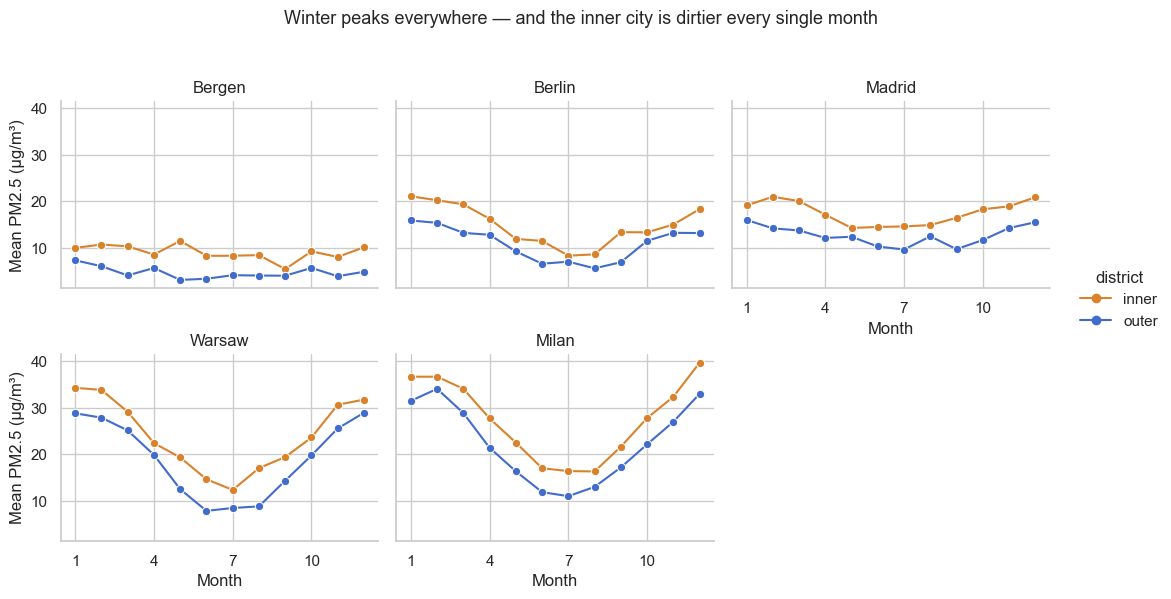

In [12]:
g = sns.relplot(data=air, x="month", y="pm25", hue="district", palette=pal,
                col="city", col_wrap=3, kind="line", marker="o",
                errorbar=None, height=2.9, aspect=1.25,
                col_order=air.groupby("city")["pm25"].mean().sort_values().index)

g.set_axis_labels("Month", "Mean PM2.5 (µg/m³)")
g.set_titles("{col_name}")
g.set(xticks=[1, 4, 7, 10])
g.figure.suptitle("Winter peaks everywhere — and the inner city is dirtier every single month",
                  y=1.03, fontsize=13)
g.tight_layout()
plt.show()

**Reading small multiples** is a different skill from reading one chart: you compare panels, so what matters is *what changes between them* and *what stays the same*.

- **The season is universal.** Every city peaks in winter and bottoms out in July — pooled, 22.1 µg/m³ in January against 10.0 in July. That is the heating-and-inversion signal, and it is why an annual mean is a poor summary of a pollutant.
- **The amplitude is not.** Milan swings from 13.7 to 36.3; Madrid barely moves, 12.1 to 18.2. Same shape, wildly different consequences: a January limit would bite Milan and not Madrid.
- **The gap is the finding.** The amber line sits above the blue one in **all sixty** city-months. A gap that survives every panel is a far stronger claim than the 4.7 µg/m³ difference in the pooled averages — that number could have come from one dreadful city dragging the mean, and faceting shows it did not.

Two mechanics worth internalising. **`col_wrap=3`** turns a long row of panels into a grid — essential above four or five categories. And the panels **share both axes by default**, which is precisely what makes them comparable; `facet_kws={"sharey": False}` is available, gives every panel its own scale, and turns a comparison into five unrelated charts. Use it deliberately or not at all.

## 9. Matrices — heatmaps

A heatmap encodes one number per cell as colour. Seaborn's `heatmap` is **axes-level and wide-form on purpose**: it wants a rectangular table, exactly the shape `pivot_table` produces. This is the one place where wide data is the right answer.

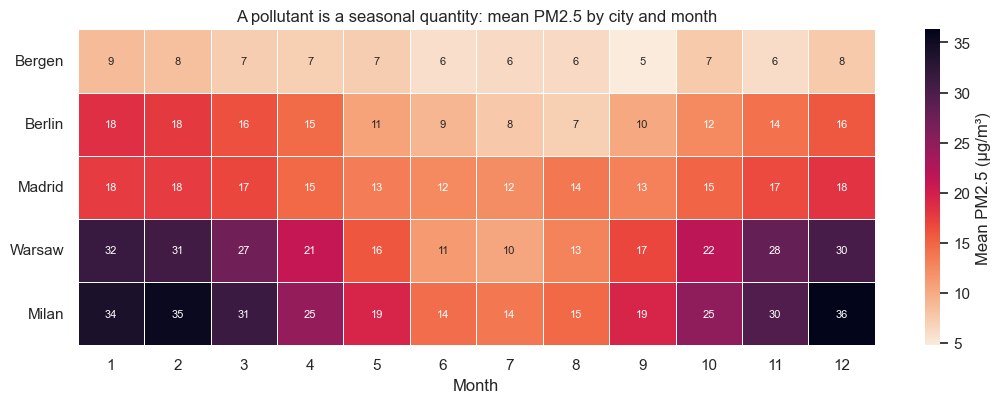

In [13]:
city_order = list(air.groupby("city")["pm25"].mean().sort_values().index)

monthly = (air.pivot_table(index="city", columns="month", values="pm25", aggfunc="mean")
              .reindex(city_order))                      # cleanest city at the top

fig, ax = plt.subplots(figsize=(11, 4.2))
sns.heatmap(monthly, annot=True, fmt=".0f", annot_kws={"fontsize": 8},
            cmap="rocket_r", linewidths=.5, ax=ax,
            cbar_kws={"label": "Mean PM2.5 (µg/m³)"})
ax.set_title("A pollutant is a seasonal quantity: mean PM2.5 by city and month")
ax.set_xlabel("Month")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)   # seaborn rotates them when the figure is tight
plt.tight_layout()
plt.show()

**Reading it.** The eye goes to the winter band down both edges of the grid and the pale corridor through the middle — May to September. Milan's January and December (34 and 36) are darker than Bergen's worst month by a factor of four, and Madrid's row is nearly uniform: a city can have a high *level* without much *season*.

Three choices made that chart readable, and they are the same three every time:

1. **Sorted rows.** `reindex(city_order)` puts the cities in order of annual mean. An unsorted heatmap is a puzzle.
2. **A sequential colormap.** These values run low→high with no meaningful midpoint, so `"rocket_r"` (or `"Blues"`, `"viridis"`, `"mako"`) is right and a diverging map would invent a centre. Notebook 9 makes the full case; it applies unchanged here.
3. **`annot=True`.** Colour is bad at conveying precise magnitude. Printing the number lets a reader *check* the colour instead of trusting it — affordable up to roughly a hundred cells.

A correlation matrix is the other classic heatmap, and it needs the opposite colormap, because correlations diverge around a meaningful zero.

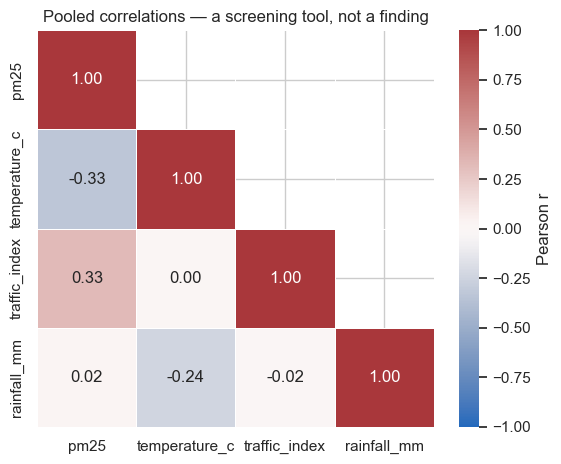

In [14]:
num_cols = ["pm25", "temperature_c", "traffic_index", "rainfall_mm"]
corr = air[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide the redundant upper triangle

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pooled correlations — a screening tool, not a finding")
plt.tight_layout()
plt.show()

**`center=0` with `vmin=-1, vmax=1` is not optional** on a correlation heatmap: it puts white at "no relationship" and makes the sign readable at a glance, and it fixes the scale so two such heatmaps can be compared. The `mask` hides the upper triangle, which is a mirror of the lower one — half the ink for all of the information.

**Now the honest part.** Every number here is *pooled across cities, months and districts*, and pooling is a blunt instrument:

- **pm25 ~ temperature = −0.33.** Real, but a big understatement: within a single city it runs from −0.18 (Bergen) to **−0.88** (Milan). Pooling mixes the seasonal signal with the fact that warm Madrid is dirtier than cold Bergen, and the two partly cancel.
- **pm25 ~ traffic = +0.33.** Already dissected in section 6: within a district type it is 0.24 and 0.17.
- **pm25 ~ rainfall = +0.02.** We *know* rain reduces PM2.5 here — it is a term in the generator. The pooled correlation cannot see it, because rain is also higher in winter, when PM2.5 is high for other reasons. A near-zero correlation is not evidence of no relationship.

A correlation matrix tells you where to look next. It is the beginning of the argument, and treating it as the end is one of the most common analytical mistakes there is.

## 10. Pairplot — the fastest look at a whole table

`pairplot` draws every numeric column against every other, with distributions down the diagonal. It is the single most efficient first move on a table you have never seen, and it is how [Notebook 11](11_exploratory_data_analysis.ipynb) opens its investigation.

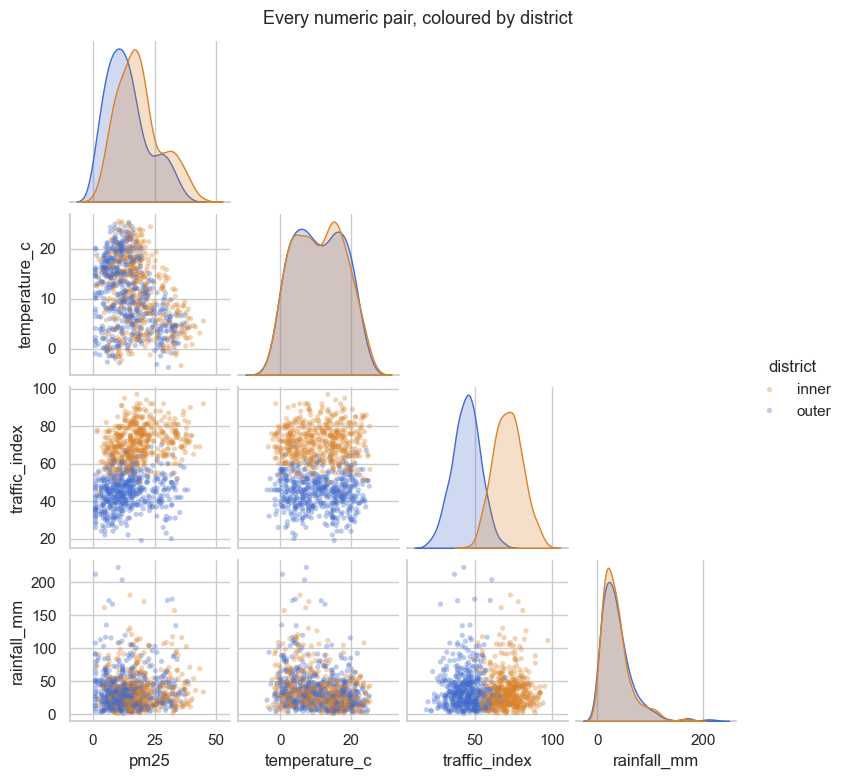

In [15]:
g = sns.pairplot(air[num_cols + ["district"]], hue="district", palette=pal,
                 corner=True, diag_kind="kde", height=1.9,
                 plot_kws=dict(alpha=.35, s=14, edgecolor="none"))
g.figure.suptitle("Every numeric pair, coloured by district", y=1.02, fontsize=13)
plt.show()

**`corner=True` earns its place**: the upper triangle of a pairplot is the lower triangle transposed, so half the panels are decoration. Ten panels here instead of sixteen, and each one bigger.

What it surfaces in seconds: the two traffic clusters (bottom row), the negative PM2.5–temperature tilt, `rainfall_mm`'s long right tail — a gamma-shaped variable that would want a log axis before anyone modelled it — and the fact that the amber and blue clouds are shifted in `pm25` but essentially identical in `rainfall_mm`.

Its costs are real: **n² panels** (twelve columns is 144 panels), and every panel drawn from every row, so it becomes slow and unreadable above a few thousand points. On a wide table, pick five or six columns with `vars=[...]` rather than plotting all of them badly. `diag_kind="hist"`, `kind="reg"` and `markers=` are the other knobs worth knowing.

## 11. Colour, honestly

Colour is the channel that carries the most meaning and gets the least thought. Seaborn makes it easy to get right, which also makes it easy to get wrong without noticing. Three kinds of palette, three jobs:

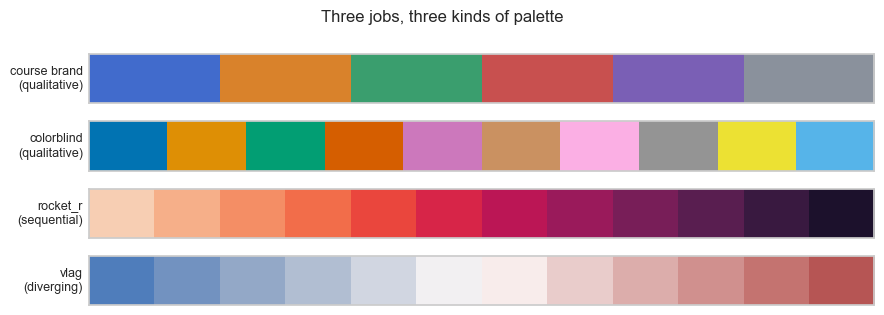

In [16]:
from matplotlib.colors import to_rgb

def swatch(ax, colors, label):
    ax.imshow([[to_rgb(c) for c in colors]], aspect="auto")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)

fig, axes = plt.subplots(4, 1, figsize=(9, 3.2))
swatch(axes[0], BAS_PALETTE,                     "course brand\n(qualitative)")
swatch(axes[1], sns.color_palette("colorblind"), "colorblind\n(qualitative)")
swatch(axes[2], sns.color_palette("rocket_r", 12), "rocket_r\n(sequential)")
swatch(axes[3], sns.color_palette("vlag", 12),     "vlag\n(diverging)")
fig.suptitle("Three jobs, three kinds of palette", fontsize=12)
plt.tight_layout()
plt.show()

| Data | Palette | Seaborn names | Why |
|---|---|---|---|
| **unordered categories** — cities, districts, species | **qualitative** | `"deep"`, `"muted"`, `"colorblind"`, `"Set2"`, or your own list | distinct hues, similar lightness: no category looks "bigger" than another |
| **ordered / continuous** — a mean, a count, a price | **sequential** | `"rocket"`, `"mako"`, `"crest"`, `"Blues"`, `"viridis"` | lightness increases monotonically, so more ink = more quantity |
| **deviation from a meaningful midpoint** — correlations, change vs baseline, profit and loss | **diverging** | `"vlag"`, `"icefire"`, `"coolwarm"`, `"RdBu_r"` | two hues meeting at a neutral centre; always pin it with `center=` |

**The rules that survive contact with real work:**

- **Never a rainbow map** (`"jet"`, `"rainbow"`) for ordered data. It manufactures sharp visual edges where the data is smooth, and it collapses in greyscale.
- **Check colour blindness.** Roughly 1 in 12 men cannot reliably separate red from green. `sns.color_palette("colorblind")` exists for exactly this; the practical test is to ask whether the chart still works in greyscale — if it does, it works for everyone.
- **Cap categorical palettes at about eight.** More than that and no palette helps; facet, group the tail into "other", or label directly instead.
- **Fix the mapping across a report.** `palette={"inner": BAS_AMBER, "outer": BAS_BLUE}` — a dict, so amber means "inner" in every chart you publish. Letting the library reassign colours per chart is how readers get misled by a document that is individually correct on every page.
- **Don't double-encode without reason.** Colouring bars by their own height adds no information and eats the reader's attention for a rainbow.

## 12. Seaborn stops, matplotlib continues

Every seaborn chart is a matplotlib chart, so nothing from Notebook 9 is lost — and the last 10% of a chart, the part that makes it publishable, is almost always matplotlib:

- **Axes-level** calls return the **Axes**. Everything you know applies: `ax.set_xlabel`, `ax.axvline`, `ax.annotate`, `ax.set_xlim`, `ax.legend`.
- **Figure-level** calls return a **grid**. `g.figure` is the Figure, `g.axes` the array of Axes, and the grid adds `set_titles`, `set_axis_labels`, `refline`, `add_legend`, `tight_layout` and `savefig`.
- `sns.despine()` removes the top and right spines from the current figure (`left=True` drops the y-spine too) — the fastest cosmetic upgrade there is.
- Saving is unchanged: `fig.savefig("chart.png", dpi=200, bbox_inches="tight")`, or `g.savefig(...)` for a figure-level chart. Save **before** `plt.show()`, which on some backends empties the figure.

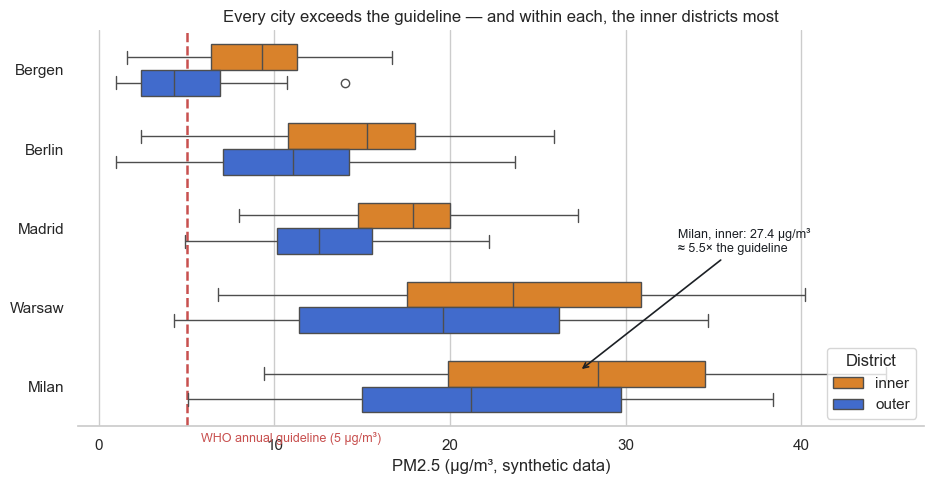

In [17]:
WHO_ANNUAL = 5   # µg/m³ — the real WHO 2021 annual guideline, on synthetic data

fig, ax = plt.subplots(figsize=(9.5, 5))
sns.boxplot(data=air, x="pm25", y="city", hue="district", palette=pal,
            order=city_order, saturation=1, width=.65, ax=ax)

# --- matplotlib takes over from here --------------------------------------
ax.axvline(WHO_ANNUAL, color=BAS_RED, lw=1.8, ls="--", zorder=0)
ax.text(WHO_ANNUAL + 0.8, len(city_order) - 0.35, "WHO annual guideline (5 µg/m³)",
        color=BAS_RED, fontsize=9, va="center")

milan_inner = air.query("city == 'Milan' and district == 'inner'")["pm25"].mean()
ax.annotate(f"Milan, inner: {milan_inner:.1f} µg/m³\n"
            f"≈ {milan_inner / WHO_ANNUAL:.1f}× the guideline",
            xy=(milan_inner, city_order.index("Milan") - 0.2), xytext=(33, 2.3),
            arrowprops=dict(arrowstyle="->", color=BAS_INK, lw=1.2),
            fontsize=9, color=BAS_INK)

ax.set_xlabel("PM2.5 (µg/m³, synthetic data)")
ax.set_ylabel("")
ax.set_title("Every city exceeds the guideline — and within each, the inner districts most")
ax.legend(title="District", loc="lower right")
sns.despine(left=True)
plt.tight_layout()
plt.show()

That is the whole workflow in one cell: **seaborn draws the statistics, matplotlib makes the argument.** The boxes came from one seaborn call; the threshold line, the callout and the title that states a finding rather than a topic came from four matplotlib ones.

The reference line is doing the most work here. A distribution is just numbers until it is placed against something a reader already cares about — a legal limit, a budget, last year, a competitor. (And note the honesty problem it creates: the guideline is a real WHO number, the data is invented, so this chart must never leave the notebook without that caveat attached.)

The same applies to figure-level charts, through the grid object.

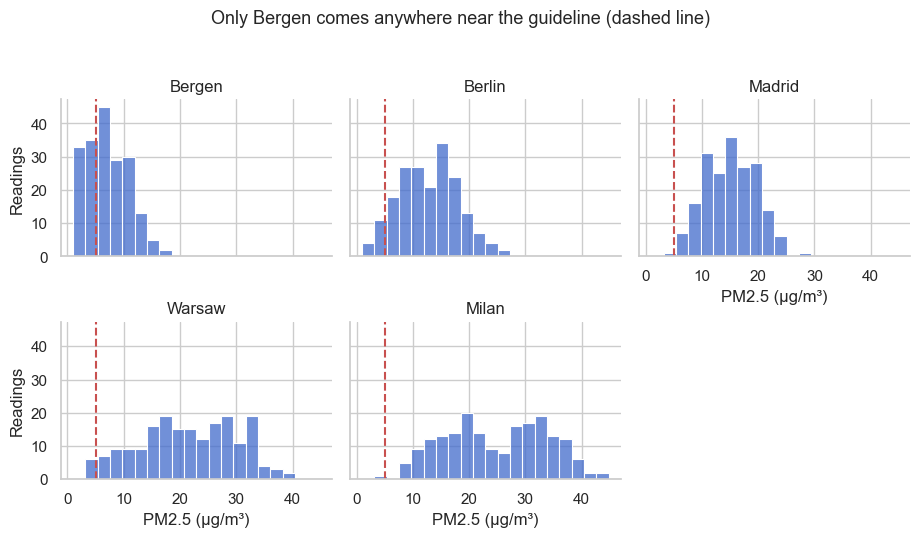

In [18]:
g = sns.displot(data=air, x="pm25", col="city", col_wrap=3, col_order=city_order,
                kind="hist", bins=20, color=BAS_BLUE, height=2.6, aspect=1.2)

g.refline(x=WHO_ANNUAL, color=BAS_RED, lw=1.5)          # one line, drawn on every panel
g.set_titles("{col_name}")
g.set_axis_labels("PM2.5 (µg/m³)", "Readings")
g.figure.suptitle("Only Bergen comes anywhere near the guideline (dashed line)",
                  y=1.03, fontsize=13)
g.tight_layout()
plt.show()

# g.savefig("air_quality_by_city.png", dpi=200, bbox_inches="tight")   # publication-ready

**And a free finding, from a chart drawn to demonstrate an API.** Warsaw's and Milan's histograms are visibly **two-humped**: a summer cluster and a winter cluster, the seasonal signal showing up as bimodality. That is exactly what section 7 said a box plot would hide — Milan's box looked like one wide distribution, and it is really two seasons stacked on top of each other.

Faceting plus a histogram found the structure; the summary chart had already smoothed it away. Charts you drew for one reason routinely tell you something else, so read them anyway.

## 13. Common pitfalls

Every one of these has cost somebody an afternoon.

1. **Wide data.** `Could not interpret value 'city' for 'hue'` means the thing you named is a column *header*, not a column. `melt` first.
2. **A figure-level function ignoring your `figsize`.** `plt.figure(figsize=(12, 6))` followed by `sns.catplot(...)` gives you a chart of the default size *and* a stray empty figure. Figure-level functions size themselves: `height=` (per panel, in inches) and `aspect=` (width ÷ height).
3. **`palette=` without `hue=`.** Deprecated in seaborn 0.13 and removed later; it emits a `FutureWarning` today. One colour for everything is `color=`; a palette needs something to map.
4. **Desaturated colours.** Categorical plots apply `saturation=0.75` to `color=`, so your exact brand hex comes out slightly washed. `saturation=1` turns that off.
5. **Silent aggregation.** `barplot`, `pointplot` and `lineplot` compute a **mean plus a bootstrapped 95% CI** unless told otherwise. Say what you mean: `estimator="median"`, `errorbar="sd"`, `errorbar=None`. Ask of any category-vs-number chart: *what arithmetic did this do?*
6. **`set_theme` is global.** It overwrites `rcParams`, so call it **first** and apply your own `rcParams` after it, not before.
7. **Overplotting.** A thousand points in one panel is a smear. `alpha=`, smaller `s=`, `jitter=` for strips — or change chart: `histplot` with `x=` and `y=` gives a 2-D histogram, and a 2-D `kdeplot` gives contours.
8. **`hue=` on a numeric column** produces a continuous colour mapping and a sampled legend, which is rarely what you wanted for something like `month`. Bin it, or cast it: `hue=air["month"].astype("category")`.
9. **Legend placement.** On axes-level charts the legend belongs to the Axes (`ax.legend(...)`, `legend=False` to suppress). On figure-level charts it lives outside the panels on the grid — move it with `g.legend.set_bbox_to_anchor(...)` or suppress it with `legend=False` and build your own.
10. **KDEs spilling past reality.** A density estimate of a strictly positive quantity will happily extend below zero. `cut=0` stops it inventing range; `clip=(0, None)` is the explicit version.
11. **`sns.load_dataset` needs the internet.** Fine in a tutorial, a broken notebook in a locked-down environment.
12. **Old tutorials pass `ci=`.** Renamed to `errorbar=` in seaborn 0.12. Anything written before that will raise, and there is a lot of it out there.

## 14. When *not* to reach for seaborn

Knowing a library's edge is part of knowing the library.

- **You need interactivity** — hover, zoom, click-to-filter. Seaborn renders static images. Use `plotly`, `altair` or `bokeh`.
- **You need an unusual figure** — an inset, a broken axis, mixed chart types in one panel, precise composition. That is matplotlib's job, and seaborn's axes-level functions are how you keep both: build the layout yourself, fill the panels with seaborn.
- **The data is genuinely large** — hundreds of thousands of rows. Aggregate first (`groupby`, `pivot_table`, a 2-D histogram) or reach for `datashader`. A scatter plot of a million points is a rectangle.
- **It is a map, a network or a tree.** `geopandas`, `networkx`, dendrogram tools. (`clustermap` is the one exception: seaborn will cluster and reorder a matrix for you.)
- **The right answer is a table.** Four numbers do not need a chart; they need four numbers, formatted well.

## 🧪 Practice exercises

### Exercise 10.1 — The same distribution, five times

Draw the distribution of **`temperature_c`**, one panel per city, split by district — as a single figure-level call. Sort the panels from coldest to warmest city, label the axes, and give the figure a title that states what you see.

Then answer in a sentence: does `district` matter for temperature the way it mattered for PM2.5?

In [19]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
temp_order = air.groupby("city")["temperature_c"].mean().sort_values().index

g = sns.displot(data=air, x="temperature_c", col="city", col_order=temp_order,
                hue="district", palette=pal, kind="kde", fill=True,
                common_norm=False, alpha=.4, height=2.7, aspect=1.15)
g.set_axis_labels("Temperature (°C)", "Density")
g.set_titles("{col_name}")
g.figure.suptitle("Temperature is a property of the city, not of the district", y=1.04)
g.tight_layout()
plt.show()
```

**Interpretation.** The two curves sit almost exactly on top of each other in every panel — unlike the PM2.5 distributions in section 5, where inner and outer were clearly offset. That is the correct answer: the generator gave inner districts more traffic and more particulates, but no extra warmth, so `district` is irrelevant here.

This is worth more than it looks. A `hue=` that produces two identical curves is a **negative result**, and negative results are how you find out which variables are doing the work. Every panel is also bimodal — that is summer and winter, two seasons wearing one distribution, and a good example of the structure a bar chart of "mean temperature" would have erased completely.
</details>

### Exercise 10.2 — Choose the categorical plot, then defend it

Show how **PM2.5 varies across the twelve months** (all cities pooled). Draw it *twice*: once as a `barplot` and once as a `boxplot`, side by side in one figure, using axes-level functions.

Then write two sentences: what does the boxplot show that the barplot cannot, and which would you put in a report for a city council?

In [20]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

sns.barplot(data=air, x="month", y="pm25", color=BAS_BLUE, saturation=1,
            errorbar="sd", ax=axes[0])
axes[0].set_title("barplot — monthly mean ± 1 sd")

sns.boxplot(data=air, x="pm25", y="month", orient="h", color=BAS_BLUE,
            saturation=1, ax=axes[1])
axes[1].set_title("boxplot — the whole monthly distribution")

axes[0].set_xlabel("Month"); axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("PM2.5 (µg/m³)"); axes[1].set_ylabel("Month")
plt.tight_layout()
plt.show()
```

*(Note the second call flips the orientation by swapping `x` and `y` — a categorical plot draws horizontally when the categorical variable is on `y`.)*

**What the boxplot adds.** Both charts show the same seasonal arc — about 22 µg/m³ in January down to 10 in July. The boxplot adds the **spread and the skew**: January's box is wide and its whisker reaches past 40, because January pools Bergen (still clean) with Milan (very dirty). The bar chart compresses that into one height, and its `errorbar="sd"` whisker implies a symmetry the data does not have.

**For a city council: the boxplot** — or better, the faceted line chart from section 8. A single monthly mean across five cities is a number that describes none of them; the decision-relevant fact is *which* cities are bad in *which* months. (If the audience will only ever read bars, keep the bars and facet them by city, so at least each bar describes one place.)
</details>

### Exercise 10.3 — A heatmap you have to think about

Build a heatmap of **mean PM2.5 by month (rows) and city (columns)** — the transpose of section 9's — and annotate it.

Then the real question: make a second heatmap of the same data showing **each city's deviation from its own annual mean**, and choose the colormap accordingly. What does the second one show that the first hides?

In [21]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
levels = air.pivot_table(index="month", columns="city", values="pm25", aggfunc="mean")
levels = levels[city_order]                       # cleanest city on the left

# Deviation from each city's own annual mean: subtract the column mean
deviation = levels - levels.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.heatmap(levels, annot=True, fmt=".0f", annot_kws={"fontsize": 8},
            cmap="rocket_r", linewidths=.5, ax=axes[0],
            cbar_kws={"label": "Mean PM2.5 (µg/m³)"})
axes[0].set_title("Level — sequential colormap")

sns.heatmap(deviation, annot=True, fmt="+.0f", annot_kws={"fontsize": 8},
            cmap="vlag", center=0, linewidths=.5, ax=axes[1],
            cbar_kws={"label": "Deviation from the city's annual mean"})
axes[1].set_title("Deviation — diverging colormap, centred on 0")

for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("Month")
plt.tight_layout()
plt.show()
```

**Why the colormaps differ.** Levels run low→high with no meaningful middle, so a sequential map is correct. Deviations have a real zero — "this city's normal" — so they need a diverging map pinned with `center=0`; without it, a diverging palette would put its neutral colour at an arbitrary value and imply structure that isn't there.

**What the second heatmap reveals.** The first is dominated by *where*: Milan's column is dark top to bottom, Bergen's pale, and the seasonal pattern is a faint modulation on top. Once each city is measured against itself, the seasonal signal is all that is left — and now you can see that **Milan and Warsaw swing by ±10 µg/m³ while Madrid barely moves ±3**. Same numbers, and a different question answered: the first asks *who is worst*, the second asks *who is most seasonal*. Subtracting the group mean to expose within-group variation is one of the most useful moves in the whole toolkit.
</details>

### Exercise 10.4 — Make a threshold argument

An ECDF is the right chart for a threshold question. Draw the cumulative distribution of `pm25` split by `district`, add a vertical reference line at **15 µg/m³**, and annotate the chart with the share of readings below that line in each group.

Compute the two numbers with pandas rather than reading them off the chart — a number you eyeballed is a number you will misquote.

In [22]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
THRESHOLD = 15

shares = air.groupby("district")["pm25"].apply(lambda s: (s < THRESHOLD).mean())
print(shares.round(3))

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.ecdfplot(data=air, x="pm25", hue="district", palette=pal, lw=2, ax=ax)

ax.axvline(THRESHOLD, color=BAS_GREY, lw=1.5, ls="--")
for district, share in shares.items():
    ax.plot(THRESHOLD, share, "o", color=pal[district], ms=8)
    ax.annotate(f"{share:.0%} of {district} readings",
                xy=(THRESHOLD, share), xytext=(THRESHOLD + 4, share - .06),
                color=pal[district], fontsize=10,
                arrowprops=dict(arrowstyle="->", color=pal[district], lw=1))

ax.set_xlabel("PM2.5 (µg/m³, synthetic data)")
ax.set_ylabel("Share of readings at or below")
ax.set_title(f"Below {THRESHOLD} µg/m³: {shares['outer']:.0%} of outer readings, "
             f"{shares['inner']:.0%} of inner ones")
sns.despine()
plt.tight_layout()
plt.show()
```

**The numbers:** 62% of outer-district readings are below 15 µg/m³, against 37% of inner-district ones.

**Why this beats a bar chart of the two means.** "18.6 versus 13.9" is a difference of averages, and a reader has to take on trust that it matters. "Two thirds of outer readings are under the threshold, but only a third of inner ones" is a statement about *how often the thing you care about happens* — which is what a threshold is for. The ECDF makes that readable at every threshold at once: slide the dashed line anywhere and the chart still answers.

The annotation pattern is worth keeping: compute the number in pandas, put it in the *title*, and mark it on the chart. The chart then cannot drift away from the number.
</details>

### Exercise 10.5 — Debug me 🐞

The cell below is supposed to draw **mean PM2.5 per city, split by district, as bars**. It contains three separate bugs — one raises an error, two are silent. Uncomment it, run it, read the traceback, then write a corrected version.

Hints: what shape is `summary`? What does `plt.figure` do to a figure-level function? And what exactly is that error bar measuring?

In [23]:
# 🐞 Buggy — uncomment, run, then fix all three problems:

# summary = air.pivot_table(index="city", columns="district", values="pm25", aggfunc="mean")
#
# plt.figure(figsize=(10, 5))
# sns.catplot(data=summary, x="city", y="pm25", hue="district", kind="bar")
# plt.title("Mean PM2.5 per city and district")
# plt.show()

<details>
<summary>💡 Click to reveal the solution</summary>

**Bug 1 — wide data.** `pivot_table` turned `district` into two column *headers* and dropped the name `pm25` entirely, so `x="city"`, `y="pm25"` and `hue="district"` all point at columns that no longer exist. `city` is not even a column any more; it became the index. That is the `ValueError` — and it names the first thing it could not find, `pm25` for `y`, which is why the message rarely points at the *real* problem.

**Bug 2 — `plt.figure` before a figure-level function.** `catplot` builds its own figure, so the 10×5 one is ignored and left behind as a stray blank output. Size a figure-level chart with `height=` and `aspect=`, and title it through the grid, not `plt.title` (which targets whichever figure pyplot happens to consider current).

**Bug 3 — the invisible aggregation.** Feeding `catplot` a table of *pre-computed means* makes it average the averages — here one value per bar, so the error bar is a bootstrap of a single number and vanishes, implying certainty that was never measured. Hand seaborn the **raw** rows and let it aggregate: then `errorbar=` describes the actual readings.

```python
# Fixed: raw long data in, seaborn does the aggregation, grid does the layout.
g = sns.catplot(data=air, x="city", y="pm25", hue="district", palette=pal,
                kind="bar", errorbar="sd", saturation=1,
                order=city_order, height=4.5, aspect=1.6)
g.set_axis_labels("", "Mean PM2.5 (µg/m³)")
g.figure.suptitle("Mean PM2.5 per city and district (whiskers: ±1 sd of the readings)",
                  y=1.03)
g.tight_layout()
plt.show()
```

Or, if you genuinely want to plot a pre-aggregated table, melt it back into long form first — and then say so in the label, because `errorbar` has nothing left to measure:

```python
summary = air.pivot_table(index="city", columns="district", values="pm25", aggfunc="mean")
tidy = summary.reset_index().melt(id_vars="city", var_name="district", value_name="pm25")

g = sns.catplot(data=tidy, x="city", y="pm25", hue="district", palette=pal, kind="bar",
                errorbar=None, saturation=1, order=city_order, height=4.5, aspect=1.6)
g.set_axis_labels("", "Mean PM2.5 (µg/m³) — pre-computed, no spread available")
plt.show()
```
</details>

## 🎁 Bonus mini-project — a one-figure air-quality briefing

Build a **2×2 briefing figure** that a city council could read without you in the room. Use `plt.subplots` for the layout and axes-level seaborn functions for the panels — the pattern from section 12, which is how most real reporting figures get made.

Requirements:

1. **Top-left** — how bad is it overall, and how does it split by district? (a distribution)
2. **Top-right** — which city is worst? (a comparison across categories, sorted)
3. **Bottom-left** — when in the year is it worst? (a seasonal view)
4. **Bottom-right** — is traffic implicated? (a relationship, with the fit)
5. Every panel's **title states a finding**, not a topic. One `suptitle` for the whole figure. The WHO guideline marked wherever it is relevant. A note in the figure that the data is synthetic.

Then write the three sentences you would say out loud while it is on screen.

In [24]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))

# (0,0) Distribution, split by district
sns.kdeplot(data=air, x="pm25", hue="district", palette=pal, fill=True,
            common_norm=False, alpha=.4, cut=0, ax=axes[0, 0])
axes[0, 0].axvline(WHO_ANNUAL, color=BAS_RED, lw=1.5, ls="--")
axes[0, 0].set_title("Inner districts are shifted right — and 92% of all\nreadings exceed the WHO guideline")
axes[0, 0].set_xlabel("PM2.5 (µg/m³)")

# (0,1) Ranking across cities
sns.boxplot(data=air, x="pm25", y="city", order=city_order, color=BAS_BLUE,
            saturation=1, width=.6, ax=axes[0, 1])
axes[0, 1].axvline(WHO_ANNUAL, color=BAS_RED, lw=1.5, ls="--")
axes[0, 1].set_title("Milan's median is nearly 4× Bergen's")
axes[0, 1].set_xlabel("PM2.5 (µg/m³)")
axes[0, 1].set_ylabel("")

# (1,0) Season
sns.lineplot(data=air, x="month", y="pm25", hue="district", palette=pal,
             marker="o", errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title("Winter is the problem: 22 µg/m³ in January, 10 in July")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Mean PM2.5 (µg/m³)")
axes[1, 0].set_xticks(range(1, 13))

# (1,1) Relationship
sns.regplot(data=air, x="traffic_index", y="pm25", color=BAS_BLUE,
            scatter_kws=dict(alpha=.2, s=14), line_kws=dict(color=BAS_RED), ax=axes[1, 1])
axes[1, 1].set_title("Traffic is associated (r = 0.33) — but only 0.24 / 0.17\nwithin a district type")
axes[1, 1].set_xlabel("Traffic index")
axes[1, 1].set_ylabel("PM2.5 (µg/m³)")

fig.suptitle("Urban PM2.5: five cities, one year  ·  SYNTHETIC DATA, for teaching only",
             fontsize=14)
fig.tight_layout()
plt.show()
```

**The three sentences.** *"Every one of these five cities is above the WHO annual guideline, and within every city the inner districts are worse — by about 4.7 µg/m³ on average, in all twelve months.* *The problem is concentrated in winter: pooled January levels are more than double July's, so an annual average hides the months that actually matter.* *Traffic is associated with the difference but does not explain it — the correlation halves once you compare like with like, so a traffic measure alone would be a bet, not a plan."*

Note what makes those sentences possible: every panel answers **one** question, and each title already contains the answer. If you can read your figure's titles aloud in order and hear a coherent argument, the figure works. That is the standard the capstone project in [Notebook 15](15_capstone_project.ipynb) is graded against too.
</details>

## 🧠 Key takeaways

1. **Seaborn is a statistical layer over matplotlib**, not a competitor. It bins, aggregates, smooths and fits; it maps columns to colour, size, shape and panels; and it leaves you a matplotlib Axes to finish the job.
2. **Long data or nothing.** One row per observation, one column per variable. `melt` is the fix, and `Could not interpret value ... for 'hue'` is the symptom.
3. **Know which family you called.** Axes-level (`histplot`, `boxplot`, `scatterplot`, …) takes `ax=` and composes; figure-level (`displot`, `catplot`, `relplot`, `lmplot`) owns its figure, sizes itself with `height`/`aspect`, facets with `col=`/`row=`, and returns a grid.
4. **Pick the chart from the question:** distribution → `displot` family (ECDF when the argument is about a threshold); relationship → `relplot`/`lmplot`; comparison of categories → `catplot`; matrix → `heatmap`; whole-table reconnaissance → `pairplot`.
5. **`hue` overlays, `col`/`row` facet.** Faceting is also the cheapest confound check you have: split by anything that might drive both axes and see whether the relationship survives — ours went from r = 0.33 to 0.24 and 0.17.
6. **Every category-vs-number chart did arithmetic.** Usually a mean with a bootstrapped CI. Name it, or set `estimator=` and `errorbar=` yourself.
7. **Colour has three jobs** — qualitative for unordered categories, sequential for ordered magnitudes, diverging (with `center=`) around a meaningful midpoint. Never rainbow, cap categories at about eight, fix the mapping across a report, and check it in greyscale.
8. **Pooled statistics dilute.** Our correlation matrix showed −0.33 for a within-city relationship as strong as −0.88, and *zero* for an effect we had deliberately built in. A heatmap of correlations is where an investigation starts.
9. **The last 10% is matplotlib**: reference lines, annotations, a title that states the finding, `despine`, `savefig`. Seaborn draws the statistics; you make the argument.

## ✅ Self-assessment

- [ ] Set a theme once and explain what `style`, `context` and `palette` each changed.
- [ ] Spot wide data, and reshape it with `melt` without looking up the arguments.
- [ ] Say whether a given seaborn function is axes-level or figure-level, and what it returns.
- [ ] Choose between `hist`, `kde` and `ecdf` for a specific question — and justify the choice.
- [ ] Build a faceted chart with `col=` and `col_wrap=`, with a title that names the finding.
- [ ] Draw a heatmap from `pivot_table` output with the right kind of colormap for the data.
- [ ] State what statistic a `barplot` or `lineplot` computed, and change it.
- [ ] Pick a colour-blind-safe categorical palette and fix a colour→category mapping across several charts.
- [ ] Add a reference line, an annotation and a real title to a seaborn chart using matplotlib.
- [ ] Name two situations where seaborn is the wrong tool, and say what you would use instead.

## 🚀 Next step

Continue with **Notebook 11 — Exploratory Data Analysis** ([`11_exploratory_data_analysis.ipynb`](11_exploratory_data_analysis.ipynb)). You now have both plotting libraries and the judgement to choose between them; what you do not have yet is a **method**. EDA is that method: which chart to reach for first on a table you did not create, in what order, and how to keep yourself from finding the pattern you went looking for. It runs one complete investigation on a real bundled dataset — and the pooled-versus-grouped trap that section 6 and section 9 kept circling gets its proper treatment there, under its real name.